<a href="https://colab.research.google.com/github/raiyan-mahmud-git/data-graph-explorer/blob/main/data_graph_explorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Choose how to load your CSV file:
1. Upload from local computer (Colab only)
2. Enter a URL
3. Use a predefined URL
Enter choice (1/2/3): 2
Enter CSV URL: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv

Column Headings:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

First 2 Rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa

Columns as list:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Available columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Enter first column: sepal_length
Enter second column: sepal_width

Choose graph type:
1. Scatter Plot
2. Line Graph
Enter choice (1/2): 2


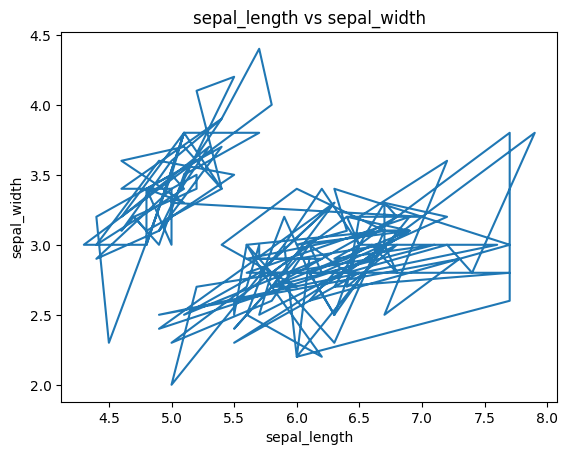


Basic Interpretation:
Correlation between sepal_length and sepal_width: -0.12
Weak or no relationship.


In [ ]:
# Data Graph Explorer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------- STEP 1: LOAD CSV (3 OPTIONS) -----------

def load_csv():
    print("Choose how to load your CSV file:")
    print("1. Upload from local computer (Colab only)")
    print("2. Enter a URL")
    print("3. Use a predefined URL")

    choice = input("Enter choice (1/2/3): ")

    if choice == "1":
        try:
            from google.colab import files
            uploaded = files.upload()
            file_name = list(uploaded.keys())[0]
            df = pd.read_csv(file_name)
            return df
        except:
            print("Upload only works in Google Colab.")
            return None

    elif choice == "2":
        url = input("Enter CSV URL: ")
        df = pd.read_csv(url)
        return df

    elif choice == "3":
        url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
        print("Using default dataset:", url)
        df = pd.read_csv(url)
        return df

    else:
        print("Invalid choice.")
        return None


# ----------- STEP 2: DISPLAY DATA -----------

def explore_data(df):
    print("\nColumn Headings:")
    print(df.columns)

    print("\nFirst 2 Rows:")
    print(df.head(2))

    columns = list(df.columns)
    print("\nColumns as list:")
    print(columns)

    return columns


# ----------- STEP 3: SELECT COLUMNS & CONVERT -----------

def select_columns(df, columns):
    print("\nAvailable columns:", columns)

    col1 = input("Enter first column: ")
    col2 = input("Enter second column: ")

    if col1 not in columns or col2 not in columns:
        print("Invalid columns selected.")
        return None, None

    x = np.array(df[col1])
    y = np.array(df[col2])

    return x, y, col1, col2


# ----------- STEP 4: PLOT GRAPH -----------

def plot_graph(x, y, col1, col2):
    print("\nChoose graph type:")
    print("1. Scatter Plot")
    print("2. Line Graph")

    choice = input("Enter choice (1/2): ")

    if choice == "1":
        plt.scatter(x, y)
    elif choice == "2":
        plt.plot(x, y)
    else:
        print("Invalid choice.")
        return

    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(f"{col1} vs {col2}")
    plt.show()


# ----------- STEP 5: INTERPRETATION -----------

def interpret_data(x, y, col1, col2):
    print("\nBasic Interpretation:")

    if len(x) == 0 or len(y) == 0:
        print("No data to interpret.")
        return

    correlation = np.corrcoef(x, y)[0, 1]

    print(f"Correlation between {col1} and {col2}: {correlation:.2f}")

    if correlation > 0.7:
        print("Strong positive relationship.")
    elif correlation > 0.3:
        print("Moderate positive relationship.")
    elif correlation > -0.3:
        print("Weak or no relationship.")
    elif correlation > -0.7:
        print("Moderate negative relationship.")
    else:
        print("Strong negative relationship.")


# ----------- MAIN PROGRAM -----------

def main():
    df = load_csv()

    if df is None:
        return

    columns = explore_data(df)

    while True:
        x, y, col1, col2 = select_columns(df, columns)

        if x is None:
            continue

        plot_graph(x, y, col1, col2)
        interpret_data(x, y, col1, col2)

        again = input("\nTry different columns? (y/n): ")
        if again.lower() != 'y':
            break


if __name__ == "__main__":
    main()